# Step 1: Setup and Import Necessary Libraries
First, ensure you have the required libraries installed in your environment. You'll need OpenCV for Hu moments and image processing, NumPy for arrays, Pandas for data handling, Seaborn and Matplotlib for plotting, Scikit-learn for PCA, and PyTorch with Torchvision for ResNet feature extraction and model building.
Run this in your notebook to install if needed (uncomment if necessary):

In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from datetime import datetime

# Set root paths (assuming you're in root/Notebooks)
root_dir = os.path.abspath('..')  # Goes to root/
dataset_dir = os.path.join(root_dir, 'Dataset')
can_dir = os.path.join(dataset_dir, 'Can_Hold')
cannot_hold_dir = os.path.join(dataset_dir, 'Cannot_Hold')
chart_dir = os.path.join(root_dir, 'Charts')

# Create Chart directory if it doesn't exist
os.makedirs(chart_dir, exist_ok=True)

# For saving with timestamp
current_date = datetime.now().strftime('%Y-%m-%d')

**Explanation**: This sets up paths relative to your Notebooks folder. We assume images are grayscale or convertible for Hu moments (common for shape analysis). Labels: 1 for "can", 0 for "cannot hold" (binary classification, but we'll use RMSE for a regression framing as requested—perhaps treating labels as continuous targets). If this isn't what you meant, clarify. We use PyTorch for the model since ResNet is involved.Explanation: This sets up paths relative to your Notebooks folder. We assume images are grayscale or convertible for Hu moments (common for shape analysis). Labels: 1 for "can", 0 for "cannot hold" (binary classification, but we'll use RMSE for a regression framing as requested—perhaps treating labels as continuous targets). If this isn't what you meant, clarify. We use PyTorch for the model since ResNet is involved.


# Step 2: Load Images and Compute 7 Hu Moments

We'll load all TIFF images from both folders, compute Hu moments (which are 7 invariant moments for shape description), and store them with labels.

In [10]:
def load_images_and_compute_hu_moments(folder, label):
    hu_moments_list = []
    image_paths = []
    for file in os.listdir(folder):
        if file.lower().endswith('.tif'):
            img_path = os.path.join(folder, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale for moments
            if img is None:
                print(f"Warning: Could not load {img_path}")
                continue
            moments = cv2.moments(img)
            hu_moments = cv2.HuMoments(moments).flatten()  # 7 values
            hu_moments_list.append(hu_moments)
            image_paths.append(img_path)
    labels = [label] * len(hu_moments_list)
    return np.array(hu_moments_list), labels, image_paths

# Load data
hu_can, labels_can, paths_can = load_images_and_compute_hu_moments(can_dir, 1)
hu_cannot, labels_cannot, paths_cannot = load_images_and_compute_hu_moments(cannot_hold_dir, 0)

# Combine
hu_moments = np.vstack((hu_can, hu_cannot))
labels = np.array(labels_can + labels_cannot)
image_paths = paths_can + paths_cannot

# Create DataFrame for easy handling
hu_df = pd.DataFrame(hu_moments, columns=[f'Hu_{i+1}' for i in range(7)])
hu_df['label'] = labels

print(f"Loaded {len(hu_moments)} images. Hu moments shape: {hu_moments.shape}")

Loaded 33 images. Hu moments shape: (33, 7)


[ WARN:0@2993.757] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65006 (0xfdee) encountered
[ WARN:0@2993.757] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65007 (0xfdef) encountered
[ WARN:0@2993.757] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65009 (0xfdf1) encountered
[ WARN:0@2993.757] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65010 (0xfdf2) encountered
[ WARN:0@2993.757] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65015 (0xfdf7) encountered
[ WARN:0@2993.757] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65016 (0xfdf8) encountered
[ WARN:0@2993.757] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65024 (0xfe00) encountered
[ WARN:0@2993.757] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65025 (0xfe

# Step 3: Plot Hu Moments with Seaborn
Visualize the 7 Hu moments across classes.

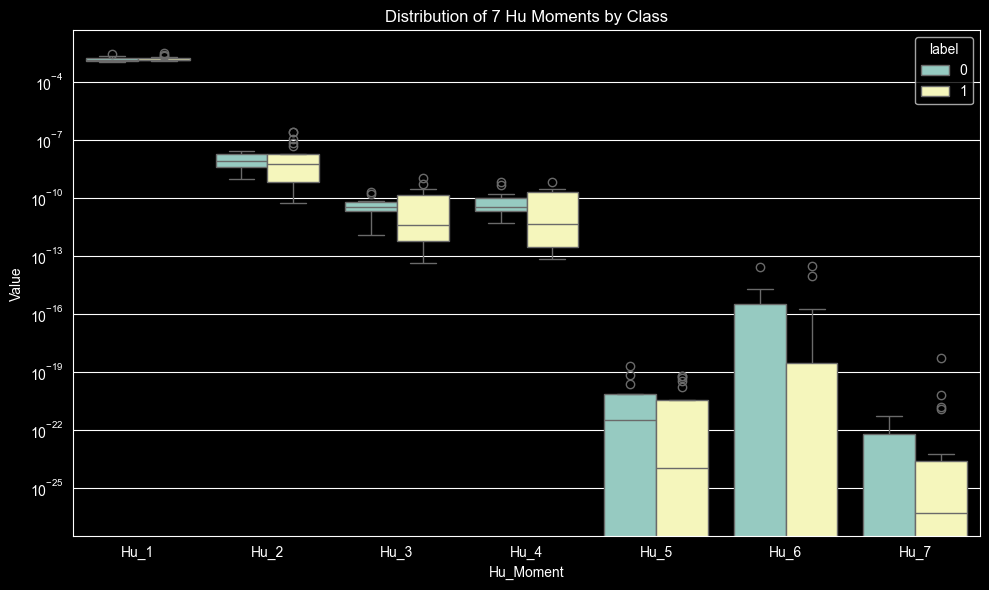

In [11]:
# Melt for seaborn plotting
hu_melted = hu_df.melt(id_vars=['label'], var_name='Hu_Moment', value_name='Value')

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=hu_melted, x='Hu_Moment', y='Value', hue='label')
plt.title('Distribution of 7 Hu Moments by Class')
plt.yscale('log')  # Log scale if values vary widely
plt.tight_layout()

# Save plot
hu_plot_path = os.path.join(chart_dir, f'hu_moments_boxplot_{current_date}.png')
plt.savefig(hu_plot_path, dpi=600)
plt.show()

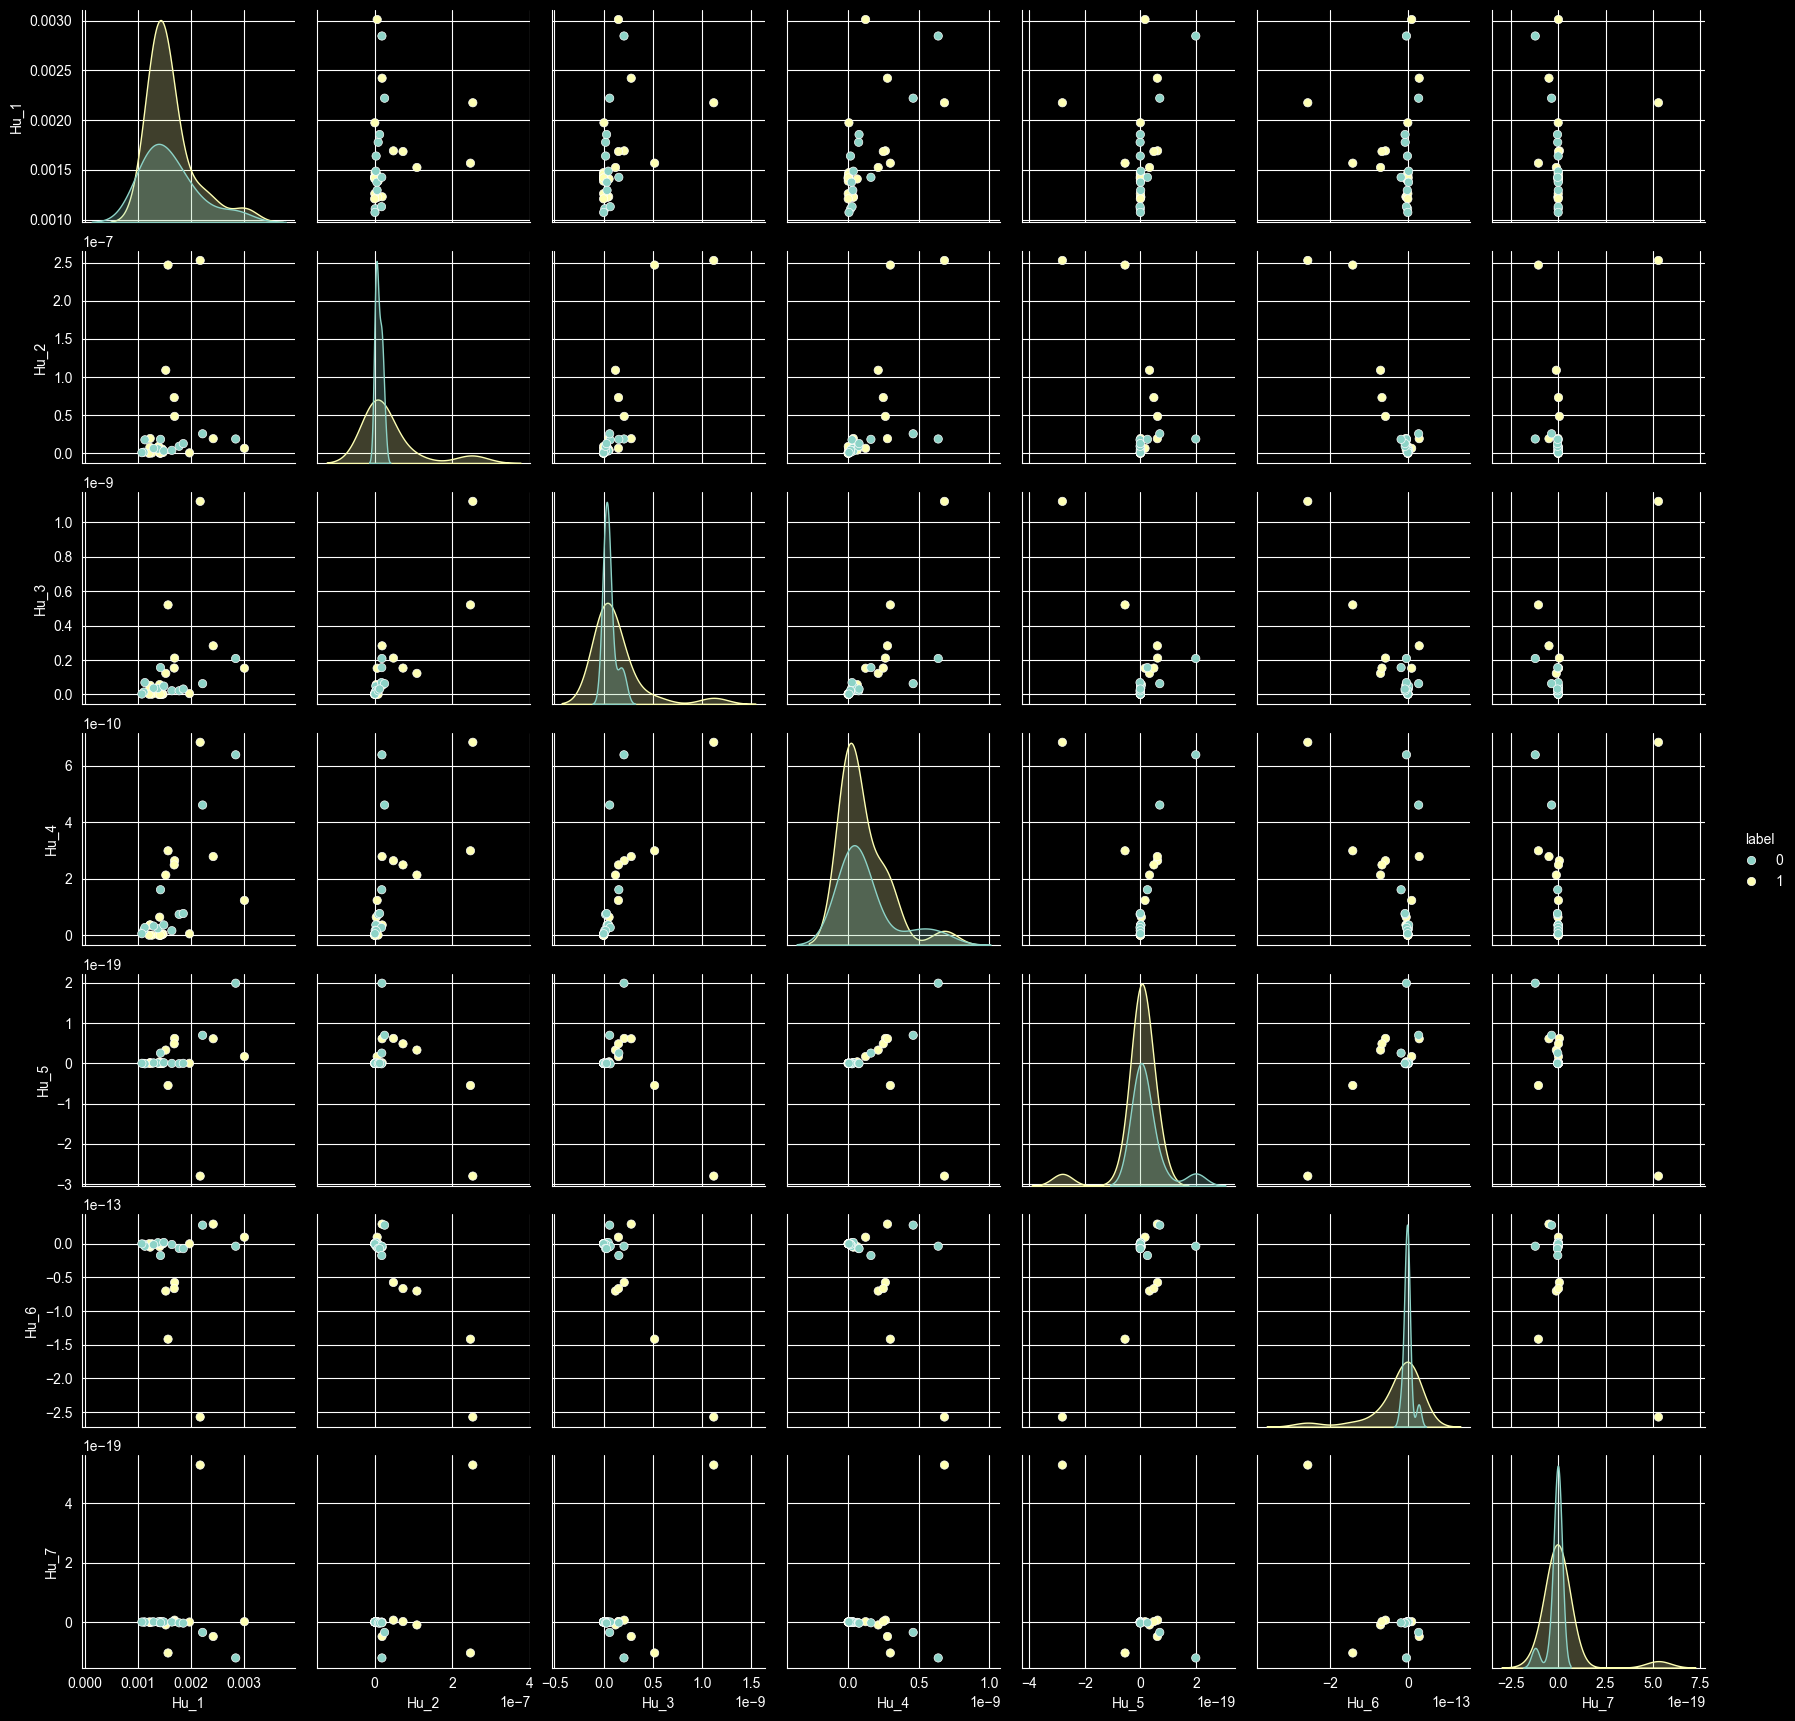

In [12]:
hu_sns_path = os.path.join(chart_dir, f'hu_moments_pairplot_{current_date}.png')
sns.pairplot(hu_df, hue="label", vars=[f"Hu_{i+1}" for i in range(7)])
plt.savefig(hu_sns_path, dpi=600)
plt.show()

**Explanation:** This creates a boxplot showing how Hu moments differ between "can" (1) and "cannot hold" (0). Log scale helps if moments have large ranges. Saved at 600 DPI in root/Chart with timestamp. Run this cell; if plot looks off (e.g., all zeros), images might be uniform—debug by printing hu_moments.


# Step 4: Apply PCA to Reduce Hu Moments to 3 Components
We'll apply PCA on the 7 Hu moments to get 3 principal components.

Explained variance ratio: [9.99999983e-01 1.68014647e-08 5.21138529e-14]


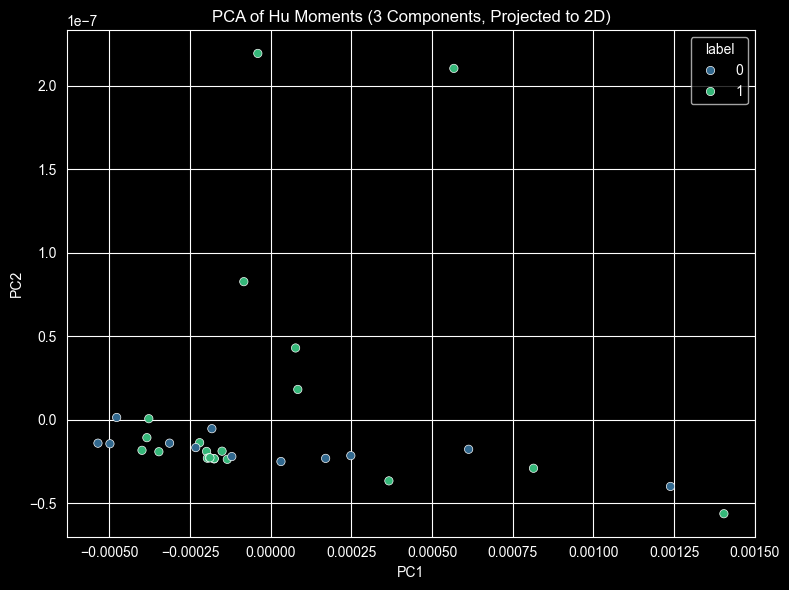

In [13]:
# PCA on Hu moments
pca = PCA(n_components=3)
pca_features = pca.fit_transform(hu_moments)

# Add to DataFrame
pca_df = pd.DataFrame(pca_features, columns=['PC1', 'PC2', 'PC3'])
pca_df['label'] = labels

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Plot PCA scatter (2D for simplicity, using PC1 and PC2)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', palette='viridis')
plt.title('PCA of Hu Moments (3 Components, Projected to 2D)')
plt.tight_layout()

# Save plot
pca_plot_path = os.path.join(chart_dir, f'pca_scatter_{current_date}.png')
plt.savefig(pca_plot_path, dpi=600)
plt.show()

**Explanation:** PCA reduces the 7 Hu moments to 3 dimensions, capturing main variance. Check explained variance: if low (e.g., <0.8 total), Hu moments might not vary much. The scatter plot visualizes separation by class. If points overlap completely, features may not distinguish classes well.

# Step 5: Extract ResNet Features
Use pre-trained ResNet50 to extract features from images (2048-dim from the last layer before classifier).

In [14]:
# Define transforms (ResNet expects 224x224 RGB)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load ResNet model
resnet = models.resnet50(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1])  # Remove classifier
resnet.eval()  # Evaluation mode

# Function to extract features
def extract_resnet_features(image_paths):
    features = []
    for path in image_paths:
        img = cv2.imread(path)  # Read in BGR
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # To RGB
        img_tensor = transform(img).unsqueeze(0)  # Batch dim
        with torch.no_grad():
            feat = resnet(img_tensor).squeeze()  # 2048 features
        features.append(feat.numpy())
    return np.array(features)

resnet_features = extract_resnet_features(image_paths)

print(f"ResNet features shape: {resnet_features.shape}")

/Users/gnbhavithran/Python_github/Virtual_environments/yamini/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/gnbhavithran/Python_github/Virtual_environments/yamini/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[ WARN:0@2999.753] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65006 (0xfdee) encountered
[ WARN:0@2999.753] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65007 (0xfdef) encountered
[ WARN:0@2999.753] gl

ResNet features shape: (33, 2048)


[ WARN:0@3001.014] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65006 (0xfdee) encountered
[ WARN:0@3001.014] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65007 (0xfdef) encountered
[ WARN:0@3001.014] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65009 (0xfdf1) encountered
[ WARN:0@3001.014] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65010 (0xfdf2) encountered
[ WARN:0@3001.014] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65015 (0xfdf7) encountered
[ WARN:0@3001.014] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65016 (0xfdf8) encountered
[ WARN:0@3001.014] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65024 (0xfe00) encountered
[ WARN:0@3001.014] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65025 (0xfe

**Explanation:** ResNet extracts deep features. We use pre-trained weights. If images aren't loading, check paths. This might take time if many images—run on GPU if possible (add .cuda() if available). Output shape should be (num_images, 2048).

# Step 6: Combine PCA (3) and ResNet Features, Create a Model
Combine 3 PCA + ResNet (2048) = 2051 features. We'll create a simple neural network regressor (since RMSE is requested—treating labels as continuous targets 0/1 for "pseudo-regression"; if you meant classification, use CrossEntropyLoss instead).
First, prepare data:

In [15]:
# Combine features
combined_features = np.hstack((pca_features, resnet_features))

# Split data
X_train, X_test, y_train, y_test = train_test_split(combined_features, labels, test_size=0.2, random_state=42)

# Custom Dataset
class ImageDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = ImageDataset(X_train, y_train)
test_dataset = ImageDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Now define and train the model:

Epoch   1/50 | Train RMSE: 0.747765 | Test RMSE: 1.122218
Epoch   2/50 | Train RMSE: 1.161848 | Test RMSE: 0.502666
Epoch   3/50 | Train RMSE: 0.517800 | Test RMSE: 0.708632
Epoch   4/50 | Train RMSE: 0.640069 | Test RMSE: 0.566173
Epoch   5/50 | Train RMSE: 0.539150 | Test RMSE: 0.385928
Epoch   6/50 | Train RMSE: 0.450360 | Test RMSE: 0.415059
Epoch   7/50 | Train RMSE: 0.498255 | Test RMSE: 0.412376
Epoch   8/50 | Train RMSE: 0.481359 | Test RMSE: 0.350069
Epoch   9/50 | Train RMSE: 0.392841 | Test RMSE: 0.388378
Epoch  10/50 | Train RMSE: 0.360699 | Test RMSE: 0.463526
Epoch  11/50 | Train RMSE: 0.380276 | Test RMSE: 0.454412
Epoch  12/50 | Train RMSE: 0.359539 | Test RMSE: 0.365704
Epoch  13/50 | Train RMSE: 0.295498 | Test RMSE: 0.298674
Epoch  14/50 | Train RMSE: 0.274660 | Test RMSE: 0.303533
Epoch  15/50 | Train RMSE: 0.300604 | Test RMSE: 0.288675
Epoch  16/50 | Train RMSE: 0.277545 | Test RMSE: 0.288572
Epoch  17/50 | Train RMSE: 0.230675 | Test RMSE: 0.355706
Epoch  18/50 |

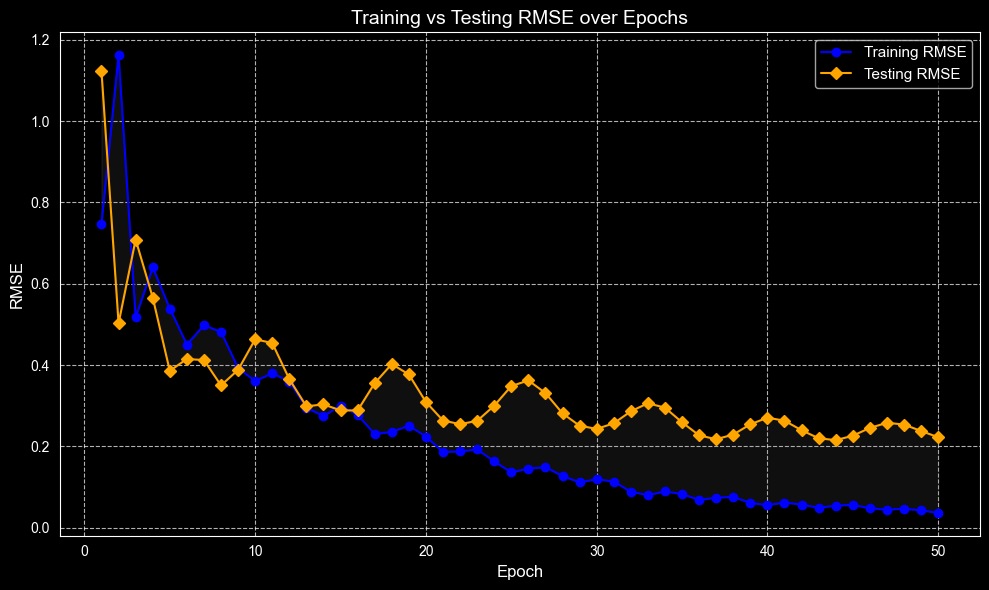

In [16]:
# Simple MLP model
class SimpleModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 1)  # Regression output

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x).squeeze()

model = SimpleModel(combined_features.shape[1])
criterion = nn.MSELoss()  # For RMSE
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
epochs = 50

train_rmse_history = []
test_rmse_history = []
epochs_list = list(range(1, epochs + 1))

for epoch in range(epochs):
    # Training phase
    model.train()
    train_preds = []
    train_true = []

    for features, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Collect all predictions to calculate RMSE later
        train_preds.extend(outputs.detach().cpu().numpy())
        train_true.extend(labels.cpu().numpy())

    # Calculate training RMSE after the whole epoch
    train_rmse = np.sqrt(mean_squared_error(train_true, train_preds))
    train_rmse_history.append(train_rmse)

    # Evaluation phase (test set)
    model.eval()
    test_preds = []
    test_true = []
    with torch.no_grad():
        for features, labels in test_loader:
            outputs = model(features)
            test_preds.extend(outputs.cpu().numpy())
            test_true.extend(labels.cpu().numpy())

    test_rmse = np.sqrt(mean_squared_error(test_true, test_preds))
    test_rmse_history.append(test_rmse)

    # Print progress
    print(f"Epoch {epoch+1:3d}/{epochs} | Train RMSE: {train_rmse:.6f} | Test RMSE: {test_rmse:.6f}")

print(f"\nFinal Test RMSE: {test_rmse_history[-1]:.6f}")

# === Plotting the learning curve ===
plt.figure(figsize=(10, 6))

plt.plot(epochs_list, train_rmse_history, marker='o', linestyle='-', color='blue', label='Training RMSE')
plt.plot(epochs_list, test_rmse_history, marker='D', linestyle='-', color='orange', label='Testing RMSE')

plt.fill_between(epochs_list,
                 train_rmse_history,
                 test_rmse_history,
                 color='gray', alpha=0.12)

plt.title('Training vs Testing RMSE over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()

# Save the plot
learning_curve_path = os.path.join(chart_dir, f'rmse_vs_epochs_{current_date}.png')
plt.savefig(learning_curve_path, dpi=600, bbox_inches='tight')
plt.show()



# # Save RMSE to file
# rmse_path = os.path.join(chart_dir, f'rmse_{current_date}.txt')
# with open(rmse_path, 'w') as f:
#     f.write(f"RMSE: {rmse:.4f}\n")

**Explanation:** Features combined into one array. Model is a 3-layer MLP regressor. Trained with MSE loss; RMSE computed on test set. If few images (<50), model may overfit—add regularization. Check loss decreasing; if RMSE is high (>0.5 for 0/1 targets), features may not separate well. Saved RMSE in text file.

# Step 7: Additional SNS Plots (e.g., Feature Correlation, Predictions)
Let's add a correlation heatmap of combined features (sampled if too many) and a prediction vs true plot.